# Notebook 2 — Grad-CAM Visualization

**Project:** Explainable CNN Perception for Autonomous Vehicles  
**Author:** Amith Carmel Anthony Raj

In [11]:
# ── PROJECT PATH ─────────────────────────────────────────────
PROJECT_ROOT = "C:/CNN_Perception_AV"

import os, sys
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT + "/src")

print(f"Working directory : {os.getcwd()}")

Working directory : C:\CNN_Perception_AV


In [12]:
import importlib
import model
importlib.reload(model)
from model import build_efficientnet, get_last_conv_layer, CLASS_NAMES
print("OK")

OK


In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import requests
from io import BytesIO

from model import build_efficientnet, get_last_conv_layer, CLASS_NAMES
from gradcam import GradCAM, GuidedGradCAM, plot_gradcam_comparison, plot_multi_class_gradcam

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


## 1. Load Model + Trained Weights

In [14]:
model     = build_efficientnet(freeze_base=False, use_augmentation=False)

# ── Load trained weights ──────────────────────────────────────────────
weights_path = PROJECT_ROOT + "/results/trained_weights.weights.h5"
if os.path.exists(weights_path):
    model.load_weights(weights_path)
    print("[OK] Loaded trained weights — predictions will be accurate")
else:
    print("[WARN] No trained weights found — run 00_train_model.ipynb first")

last_conv = get_last_conv_layer(model)
gcam      = GradCAM(model, last_conv_layer_name=last_conv)
print(f"Last conv layer (Grad-CAM target): {last_conv}")

[OK] Loaded trained weights — predictions will be accurate
Last conv layer (Grad-CAM target): top_conv


In [6]:
import os
#print(os.listdir("C:/CNN_Perception_AV/data"))
# should show: ['CNN_img.jpg']

['000002.png', '000003.png', '000004.png', '000005.png', '000006.png', '000007.png', '000008.png', '000009.png', '000010.png', '000011.png', '000014.png', '000015.png', '000016.png', '000019.png', '000020.png', '000021.png', '000100.png', '000101.png', '000103.png', '000104.png', '000107.png', '000108.png', '000110.png', '000111.png', '000112.png', '000113.png', '000114.png', '000115.png', '000116.png', '000117.png', '000118.png', '000119.png', '000120.png', '000121.png', '000122.png', '000124.png', '000127.png', '000128.png', '000130.png', '000131.png', '000132.png', '000133.png', '000134.png', '000135.png', '000136.png', '000137.png', '000138.png', '000141.png', '000142.png', '000144.png', '000145.png', '000147.png', '000148.png', '000149.png', '000150.png', '000151.png', '000152.png', '000153.png', '000154.png', '000155.png', '000156.png', '000157.png', '000158.png', '000159.png', '000161.png', '000162.png', '000163.png', '000164.png', '000165.png', '000167.png', '000168.png', '0001

## 2. Load a Test Image

**Option A** — Load from your KITTI pen drive (recommended after training)  
**Option B** — Load from URL  
**Option C** — Synthetic (no image needed)

Prediction: cyclist  (93.4%)
All classes: {'background': '1.4%', 'car': '4.6%', 'pedestrian': '0.6%', 'cyclist': '93.4%'}


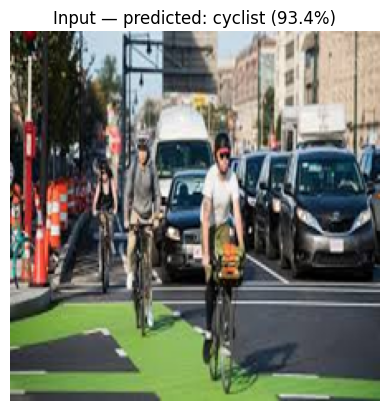

In [15]:
def load_from_file(path, size=(224, 224)):
    img      = Image.open(path).convert("RGB").resize(size)
    original = np.array(img)
    arr      = original.astype(np.float32)
    return np.expand_dims(arr, 0), original

def load_from_url(url, size=(224, 224)):
    response = requests.get(url, timeout=10)
    img      = Image.open(BytesIO(response.content)).convert("RGB").resize(size)
    original = np.array(img)
    arr      = original.astype(np.float32)
    return np.expand_dims(arr, 0), original

def load_synthetic(seed=42):
    np.random.seed(seed)
    original = np.random.randint(80, 180, (224, 224, 3), dtype=np.uint8)
    arr      = original.astype(np.float32)
    return np.expand_dims(arr, 0), original

# ── CHOOSE ONE ────────────────────────────────────────────────────────
# Option A — from KITTI pen drive (best after training)
img_array, original_img = load_from_file("C:/CNN_Perception_AV/data/CNN_image.jpg")

# Option B — from URL
# img_array, original_img = load_from_url("https://upload.wikimedia.org/wikipedia/commons/thumb/1/1b/2011_Toyota_Camry_--_NHTSA.jpg/800px-2011_Toyota_Camry_--_NHTSA.jpg")

# Option C — synthetic (no image needed)
#img_array, original_img = load_synthetic(seed=42)
# ─────────────────────────────────────────────────────────────────────

preds      = model.predict(img_array, verbose=0)[0]
pred_idx   = np.argmax(preds)
pred_class = CLASS_NAMES[pred_idx]
print(f"Prediction: {pred_class}  ({preds[pred_idx]*100:.1f}%)")
print(f"All classes: { {c: f'{p*100:.1f}%' for c, p in zip(CLASS_NAMES, preds)} }")

plt.imshow(original_img)
plt.title(f"Input — predicted: {pred_class} ({preds[pred_idx]*100:.1f}%)")
plt.axis("off")
plt.show()

## 3. Grad-CAM

[OK] Saved to C:/CNN_Perception_AV/results/gradcam_single.png


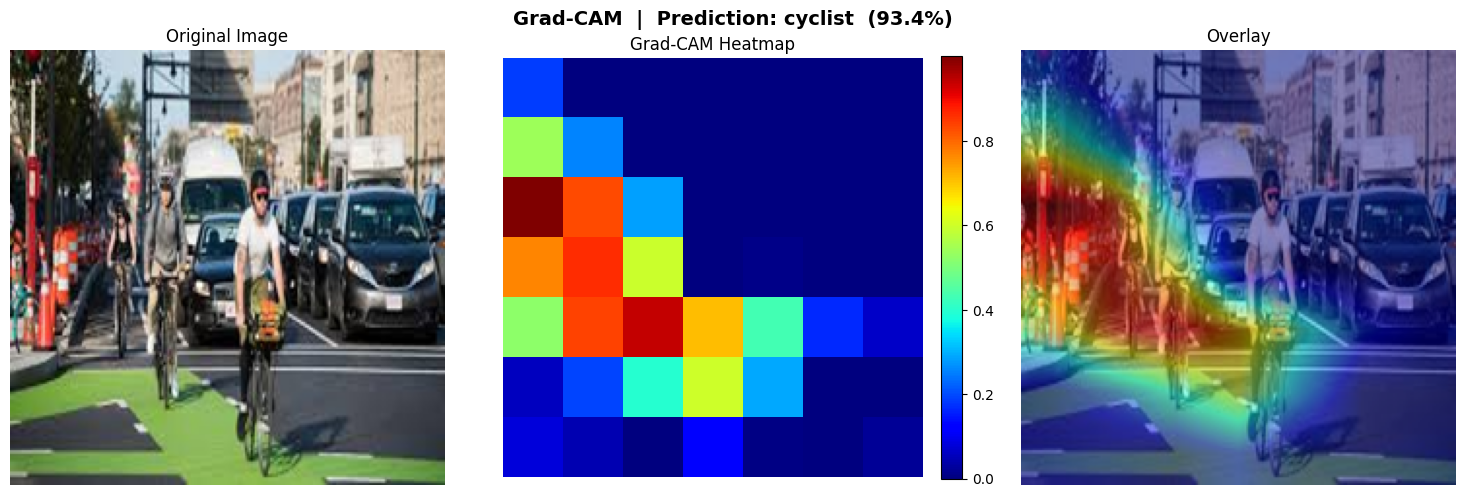

In [16]:
heatmap    = gcam.compute(img_array, class_index=None)
overlay    = GradCAM.overlay(original_img, heatmap, alpha=0.45)
class_name, confidence = gcam.get_predicted_class(img_array, CLASS_NAMES)

plot_gradcam_comparison(
    original_img, heatmap, overlay,
    class_name, confidence,
    save_path=PROJECT_ROOT + "/results/gradcam_single.png"
)

## 4. Grad-CAM for Every Class

[OK] Saved to C:/CNN_Perception_AV/results/gradcam_all_classes.png


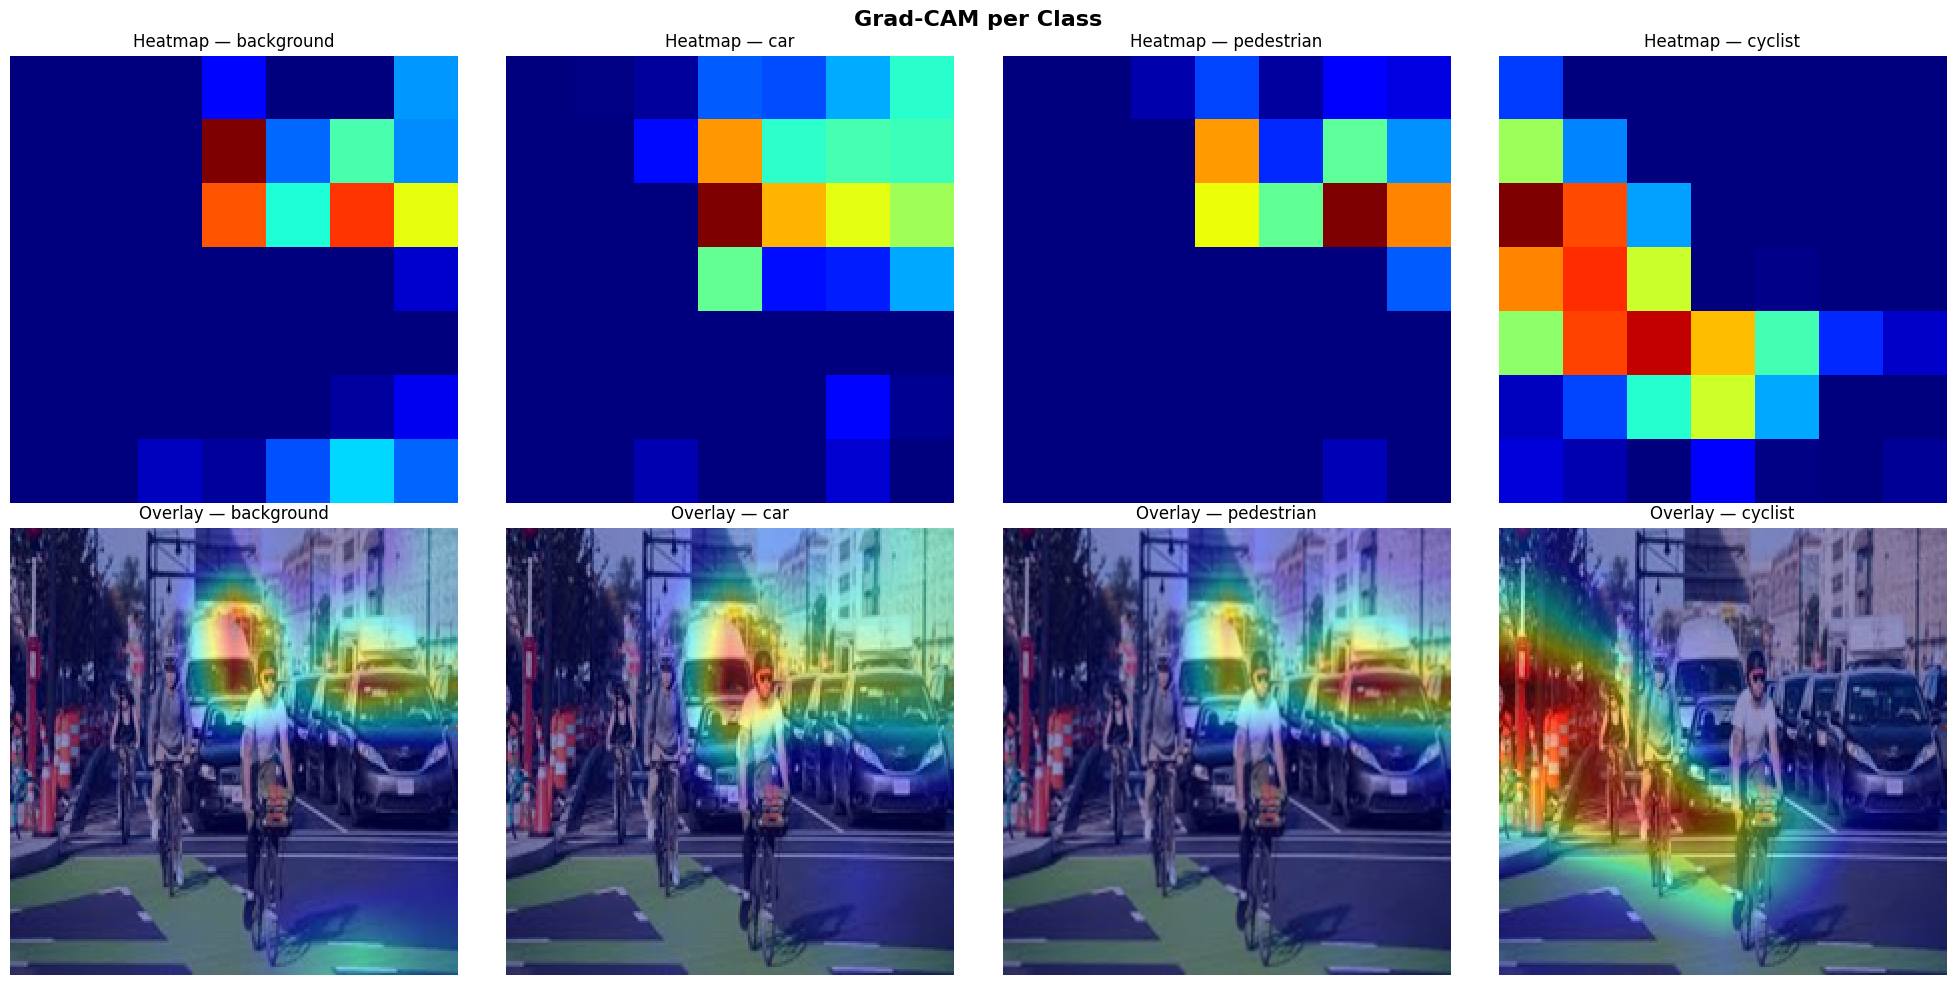

In [17]:
plot_multi_class_gradcam(
    model, img_array, original_img,
    CLASS_NAMES, last_conv,
    save_path=PROJECT_ROOT + "/results/gradcam_all_classes.png"
)

## 5. Guided Grad-CAM

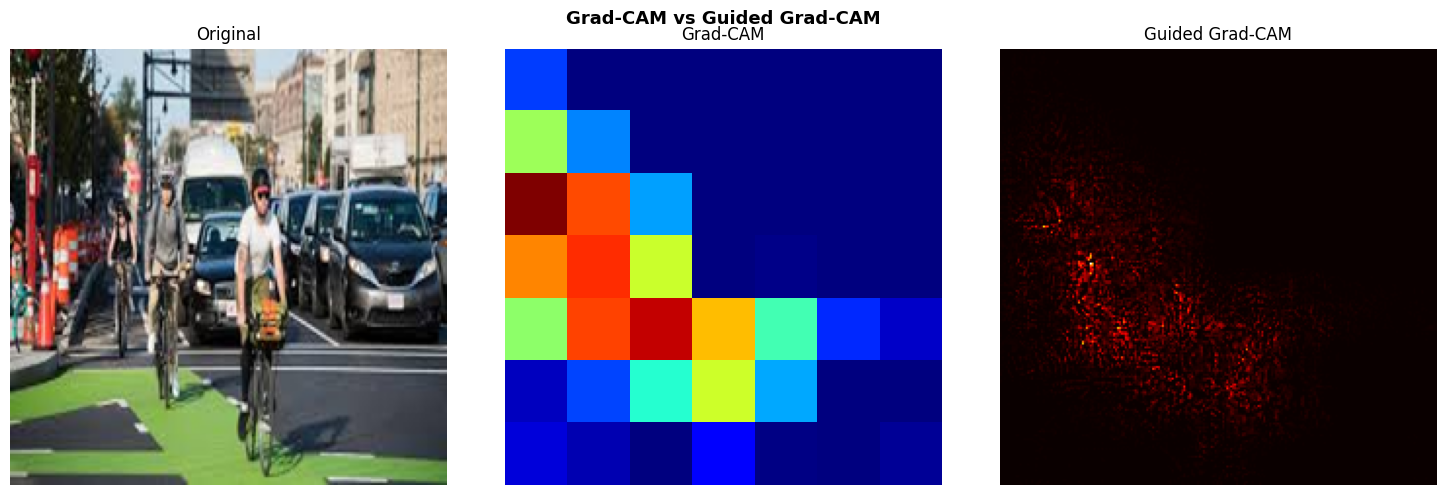

In [18]:
guided_gcam = GuidedGradCAM(model, last_conv_layer_name=last_conv)
guided_map  = guided_gcam.compute(img_array)

guided_display  = np.max(guided_map, axis=-1)
guided_display /= (guided_display.max() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Grad-CAM vs Guided Grad-CAM", fontsize=13, fontweight="bold")
axes[0].imshow(original_img);                   axes[0].set_title("Original");         axes[0].axis("off")
axes[1].imshow(heatmap, cmap="jet");            axes[1].set_title("Grad-CAM");         axes[1].axis("off")
axes[2].imshow(guided_display, cmap="hot");     axes[2].set_title("Guided Grad-CAM");  axes[2].axis("off")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/results/guided_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()